In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# load dataset
train_df = pd.read_csv("../dataset/processed-data/train.csv")
test_df = pd.read_csv("../dataset/processed-data/test.csv")

In [4]:
train_df.columns

Index(['num__Id', 'num__MSSubClass', 'num__LotFrontage', 'num__LotArea',
       'num__OverallQual', 'num__OverallCond', 'num__YearBuilt',
       'num__YearRemodAdd', 'num__MasVnrArea', 'num__BsmtFinSF1',
       ...
       'nom__SaleType_New', 'nom__SaleType_Oth', 'nom__SaleType_WD',
       'nom__SaleCondition_Abnorml', 'nom__SaleCondition_AdjLand',
       'nom__SaleCondition_Alloca', 'nom__SaleCondition_Family',
       'nom__SaleCondition_Normal', 'nom__SaleCondition_Partial', 'SalePrice'],
      dtype='object', length=228)

In [3]:
train_df.shape, test_df.shape

((1460, 228), (1459, 227))

In [5]:
# features and target split
X = train_df.drop('SalePrice',axis=1)
y = train_df['SalePrice']

In [6]:
# split dataset
X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2, random_state=42)

## Linear Model 

In [7]:
linear = LinearRegression()

In [8]:
linear.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = linear.predict(X_valid)

In [14]:
print(f"R2 score: {r2_score(y_valid,y_pred)}")
rsme = np.sqrt(mean_squared_error(y_valid,y_pred))
print(f"Mean Squared Error: {rsme}")
print(f"Mean Absolute Error: {mean_absolute_error(y_valid,y_pred)}")

R2 score: 0.8808587151923103
Mean Squared Error: 30229.993701924046
Mean Absolute Error: 19753.776189345885


In [26]:
print(linear.intercept_)

-199675.2631419193


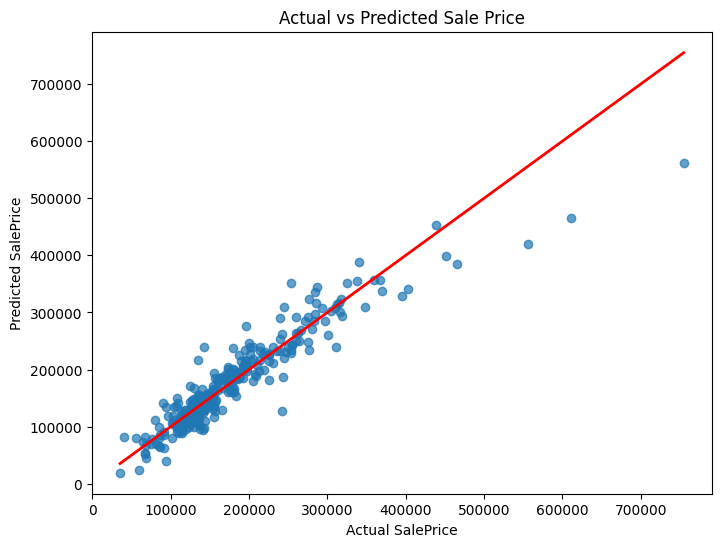

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_valid,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted Sale Price")
plt.show()

## Ridge

In [15]:
ridge = Ridge(alpha=0.1)

In [16]:
ridge.fit(X_train,y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [21]:
y_pred_r = ridge.predict(X_valid)

In [28]:
print(f"R2 score: {r2_score(y_valid,y_pred_r)}")
rsme = np.sqrt(mean_squared_error(y_valid,y_pred_r))
print(f"Mean Squared Error: {rsme}")
print(f"Mean Absolute Error: {mean_absolute_error(y_valid,y_pred_r)}")

R2 score: 0.8843323281660157
Mean Squared Error: 29786.049999832638
Mean Absolute Error: 19355.294935050388


In [29]:
print(ridge.intercept_)

-220321.4238849783


## Lasso


In [31]:
lasso = Lasso(alpha=0.1)

In [32]:
lasso.fit(X_train,y_train)

H:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.199e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [33]:
y_pred_l = lasso.predict(X_valid)

In [34]:
print(f"R2 score: {r2_score(y_valid,y_pred_l)}")
rsme = np.sqrt(mean_squared_error(y_valid,y_pred_l))
print(f"Mean Squared Error: {rsme}")
print(f"Mean Absolute Error: {mean_absolute_error(y_valid,y_pred_l)}")

R2 score: 0.8864070606924501
Mean Squared Error: 29517.70484509452
Mean Absolute Error: 19446.688417394038


In [35]:
print(lasso.intercept_)

-74826.99148260246


## ElasticNet

In [36]:
elastic = ElasticNet(alpha=0.1,l1_ratio=0.8)

In [37]:
elastic.fit(X_train,y_train)

,alpha,0.1
,l1_ratio,0.8
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [38]:
y_pred_e = elastic.predict(X_valid)

In [39]:
print(f"R2 score: {r2_score(y_valid,y_pred_e)}")
rsme = np.sqrt(mean_squared_error(y_valid,y_pred_e))
print(f"Mean Squared Error: {rsme}")
print(f"Mean Absolute Error: {mean_absolute_error(y_valid,y_pred_e)}")

R2 score: 0.8696563730582016
Mean Squared Error: 31619.268455666355
Mean Absolute Error: 18708.473969995128


In [40]:
print(elastic.intercept_)

9576.428315575962


#### Hypertunning

In [50]:
class HyperTunning:
    def __init__(self, X_train,X_valid,y_train, y_valid):
        self.X_train = X_train
        self.X_valid = X_valid 
        self.y_train = y_train
        self.y_valid = y_valid

    def train(self,alphas, l1_ratio=0.8):
        
        ridge_result = []
        lasso_result = []
        elastic_result = []
        
        for alpha in alphas:

            # for Ridge
            ridge = Ridge(alpha=alpha)
            ridge.fit(self.X_train, self.y_train)
            y_pred_r = ridge.predict(X_valid)
            ridge_r2 = r2_score(y_valid,y_pred_r)

            ridge_result.append(ridge_r2)

            #for Lasso
            lasso = Lasso(alpha=alpha)
            lasso.fit(self.X_train, self.y_train)
            y_pred_l = lasso.predict(X_valid)
            lasso_r2 = r2_score(y_valid,y_pred_l)

            lasso_result.append(lasso_r2)

            # for Elastic 
            elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
            elastic.fit(self.X_train, self.y_train)
            y_pred_e = elastic.predict(X_valid)
            elastic_r2 = r2_score(y_valid,y_pred_e)

            elastic_result.append(elastic_r2)

        print(f"Alphas : {alphas}")
        print(f"Ridge : {ridge_result}")
        print(f"Lasso : {lasso_result}")
        print(f"Elastic : {elastic_result}")       

In [51]:
h = HyperTunning(X_train,X_valid,y_train,y_valid)

In [53]:
h.train([0.1,0.001,0.05,0.5,0.005])

H:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.199e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(
H:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.440e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(
H:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.044e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coo

Alphas : [0.1, 0.001, 0.05, 0.5, 0.005]
Ridge : [0.8843323281660157, 0.880926556210375, 0.8832138158361091, 0.8847357401969986, 0.8811868937000724]
Lasso : [0.8864070606924501, 0.8864431879765705, 0.8863727511859937, 0.8866178863054193, 0.8864286718194773]
Elastic : [0.8696563730582016, 0.8852086706523412, 0.8729706263704073, 0.8583890892881915, 0.8825440881445603]


H:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.504e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(
